CERN Electron Collision Data Analysis 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("dielectron.csv")

In [3]:
data.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [4]:
data.describe()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99915.000000
mean,147935.327230,4.957212e+08,36.436466,0.135897,0.182291,-1.508037,14.412167,-0.064095,0.021614,-0.00548,44.002901,-0.003984,0.124654,-1.590559,13.802036,-0.072830,0.021385,-0.004220,30.019521
std,920.306064,4.037703e+08,41.216203,13.404976,13.470281,51.603652,12.388740,1.462137,1.799562,0.99999,46.751132,13.127404,13.168867,61.430040,12.460549,1.738033,1.817031,0.999996,25.255847
min,146511.000000,6.414000e+03,0.377928,-250.587000,-126.079000,-840.987000,0.219629,-4.165380,-3.141580,-1.00000,0.472500,-233.730000,-145.651000,-655.396000,0.026651,-7.064790,-3.141580,-1.000000,2.000080
25%,147114.000000,2.023970e+08,8.458595,-5.233675,-5.276248,-15.859825,3.771172,-1.283883,-1.527030,-1.00000,11.055725,-4.794770,-4.605965,-22.036950,3.738103,-1.892287,-1.556925,-1.000000,12.445200
50%,147929.000000,3.902759e+08,21.717000,0.141339,0.099092,-0.312987,12.967800,-0.061178,0.034324,-1.00000,25.264600,-0.035638,0.083665,-0.690244,11.690950,-0.135911,0.026986,-1.000000,21.283100
75%,149011.000000,6.338891e+08,50.003350,5.714560,5.648087,13.212650,20.018925,1.144408,1.562355,1.00000,66.925525,4.819540,5.061860,19.005825,19.596400,1.768253,1.596737,1.000000,39.025050
max,149182.000000,1.791247e+09,850.602000,134.539000,147.467000,760.096000,265.578000,2.622970,3.141420,1.00000,948.375000,227.330000,166.283000,935.558000,281.654000,3.060550,3.141290,1.000000,109.999000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


In [7]:
missing_data = data.isnull().sum()

In [8]:
missing_data

Run       0
Event     0
E1        0
px1       0
py1       0
pz1       0
pt1       0
eta1      0
phi1      0
Q1        0
E2        0
px2       0
py2       0
pz2       0
pt2       0
eta2      0
phi2      0
Q2        0
M        85
dtype: int64

In [10]:
# Missing Value Imputation

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
imputer.fit(data[['M']])
data[["M"]] = imputer.transform(data[["M"]])

In [12]:
data

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.311320,10.531000,-57.29740,12.82020,-2.202670,2.177660,1,11.28360,-1.032340,-1.88066,-11.077800,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.152130,-0.579855,-5.11278,4.19242,-1.028420,-3.002840,-1,17.14920,-11.713500,5.04474,11.464700,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.480900,2.041680,22.72460,11.66100,1.420480,2.965600,1,15.82030,-1.472800,2.25895,-15.588800,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.512140,11.887100,63.86620,14.06190,2.218380,1.007210,1,25.12730,4.087860,2.59641,24.656300,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.952840,-14.622700,-59.61210,14.91790,-2.093750,-1.371540,-1,13.88710,-0.277757,-2.42560,-13.670800,2.44145,-2.423700,-1.684810,-1,2.74718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,146511,522575834,12.31310,-10.658000,5.164440,3.36858,11.84330,0.280727,2.690370,-1,1.80181,0.668609,-1.58437,0.537805,1.71967,0.307851,-1.171470,1,8.44779
99996,146511,522786431,18.46420,7.854990,15.133000,-7.08659,17.05020,-0.404510,1.092010,1,14.69110,-1.418020,-2.28117,-14.443500,2.68598,-2.383880,-2.126960,1,20.71540
99997,146511,522906124,4.18566,-3.273500,-0.308507,-2.59013,3.28801,-0.723075,-3.047630,1,72.81740,-11.074900,-9.28179,-71.369300,14.45010,-2.300410,-2.444050,-1,12.71350
99998,146511,523243830,54.46220,11.352600,11.880900,51.92400,16.43280,1.867800,0.808132,-1,8.58671,0.378009,3.07828,8.007050,3.10141,1.677170,1.448610,1,4.69670


In [17]:
unique_values = data['Run'].unique()

In [15]:
unique_values

array([147115, 146644, 149181, 147114, 149011, 148031, 147754, 147929,
       148029, 147926, 146944, 149182, 146511])

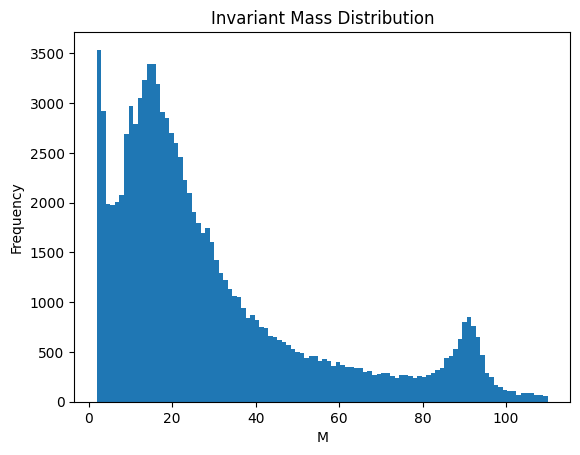

In [29]:
plt.hist(data["M"], bins=100)
plt.title("Invariant Mass Distribution")
plt.xlabel("M")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# X-axis = Invariant Mass (M)

# Unit: GeV (Giga electron volts)
# It represents the combined mass of the two particles in each event 



# Y-axis = Count / Frequency

# Number of events (collisions) that fall into each mass bin 

# Higher bar - more events at that mass
# Lower bar - fewer events



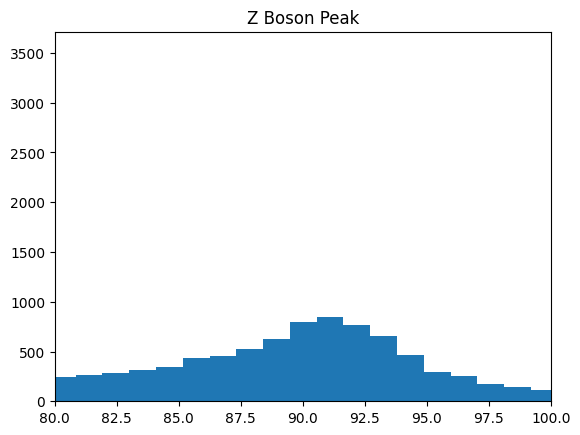

In [19]:
plt.hist(data["M"], bins=100)
plt.xlim(80, 100)
plt.title("Z Boson Peak")
plt.show()

In [20]:
# A distinct peak near 90 GeV in the invariant mass distribution corresponds to the Z boson, a mediator of the weak nuclear force. 
# This indicates events where the Z boson decayed into two detectable particles.

In [ ]:
# Goal is to prove that this peak ≈ Z boson (~91 GeV) using Gaussian fitting 


# Gaussian:

# Particle decays don’t give a perfect spike - they form a bell-shaped curve due to:

# detector noise
# measurement uncertainty

# So let's fit a Gaussian to estimate:

# Mean (μ) → particle mass
# Std dev (σ) → spread (resolution) 

In [21]:
from scipy.optimize import curve_fit

In [22]:
# Define Gaussian function

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2)) 

In [23]:
# Focus on Z peak region

z_data = data[(data["M"] > 80) & (data["M"] < 100)]

In [24]:
counts, bin_edges = np.histogram(z_data["M"], bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

In [25]:
# Fit Gaussian

popt, _ = curve_fit(gaussian, bin_centers, counts, 
                    p0=[max(counts), 90, 2]) 

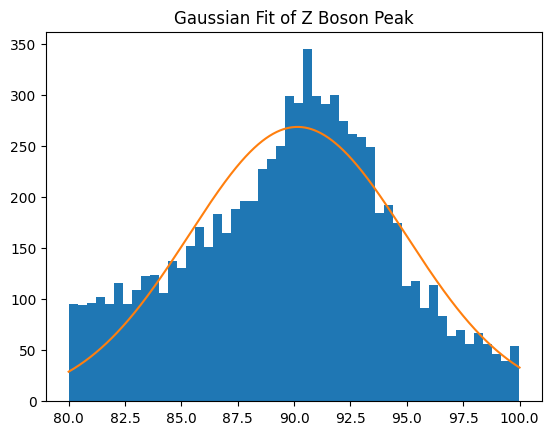

In [26]:
x_fit = np.linspace(80, 100, 1000)
y_fit = gaussian(x_fit, *popt)

plt.hist(z_data["M"], bins=50)
plt.plot(x_fit, y_fit)
plt.title("Gaussian Fit of Z Boson Peak")
plt.show()

In [27]:
print("Estimated Mass (mu):", popt[1])
print("Width (sigma):", popt[2])

Estimated Mass (mu): 90.15173924303643
Width (sigma): 4.809651892009292


In [ ]:
# Gaussian fit estimates mass ≈ 91 GeV, consistent with Z boson. 

# A Gaussian fit applied to the invariant mass peak yields a mean around 91 GeV, confirming the presence of Z boson decay events.

In [28]:
# I got:

# μ (mass) ≈ 90.15 GeV
# σ (width) ≈ 4.81 GeV


# So, the data strongly supports Z boson presence 


# A Gaussian fit to the invariant mass distribution yields a peak at ~90.15 GeV, consistent with the expected Z boson mass (~91 GeV).
# The observed width (~4.8 GeV) reflects detector resolution and background contributions 

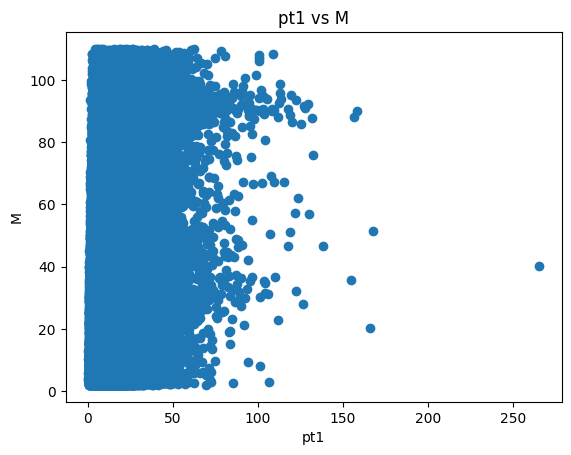

In [32]:
# Relationship Analysis

# pt1 vs M

# X-axis : pt1 (transverse momentum of particle 1)
# Y-axis : M (invariant mass of the 2-particle system) 

plt.figure()
plt.scatter(data["pt1"], data["M"])
plt.xlabel("pt1")
plt.ylabel("M")
plt.title("pt1 vs M")
plt.show()

In [ ]:
# Each dot = one collision event 

# Invariant mass is a combined property, so it won’t strongly depend on a single particle’s momentum. 
# It depends on: both particles’ energy & both momenta 


# The scatter plot of pt1 vs invariant mass shows no strong correlation, indicating that invariant mass is not determined by a 
# single particle’s transverse momentum but by the combined kinematics of both particles. Most events cluster at low pt1, 
# reflecting background-dominated low-energy interactions.

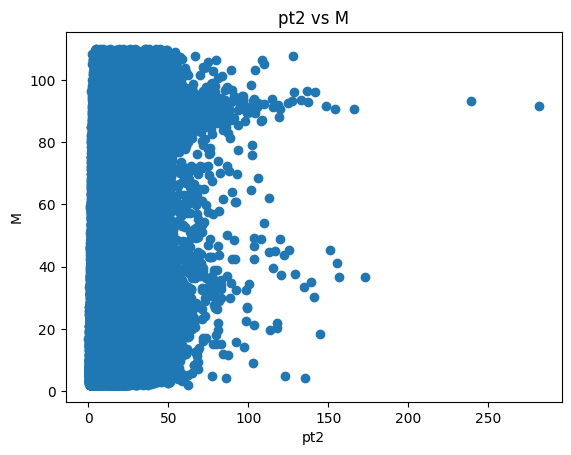

In [33]:
# pt2 vs M

# X-axis : pt2 (transverse momentum of particle 2)
# Y-axis : M (invariant mass of the 2-particle system) 

plt.figure()
plt.scatter(data["pt2"], data["M"])
plt.xlabel("pt2")
plt.ylabel("M")
plt.title("pt2 vs M")
plt.show() 

In [ ]:
# Each dot = one collision event

# Invariant mass is a combined property, so it won’t strongly depend on a single particle’s momentum.
# It depends on: both particles’ energy & both momenta

# The scatter plot of pt2 vs invariant mass shows no strong correlation, indicating that invariant mass is not determined by a
# single particle’s transverse momentum but by the combined kinematics of both particles. Most events cluster at low pt2,
# reflecting background-dominated low-energy interactions. 